<a href="https://colab.research.google.com/github/Sama-Elmogy/Energy-Theft-Detection-System-using-LSTM-and-Machine-Learning/blob/main/Copy_of_Preprocessing_Of__Energy__Theft_Detectio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load data
df = pd.read_csv("/content/smart_meter_data.csv")

explore data

In [ ]:
df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,1/1/2024 0:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,1/1/2024 0:30,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,1/1/2024 1:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,1/1/2024 1:30,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,1/1/2024 2:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


In [ ]:
df.shape

(5000, 7)

In [ ]:
df.columns

Index(['Timestamp', 'Electricity_Consumed', 'Temperature', 'Humidity',
       'Wind_Speed', 'Avg_Past_Consumption', 'Anomaly_Label'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
dtypes: float64(5), object(2)
memory usage: 273.6+ KB


In [ ]:
df.describe()

,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.376677,0.525069,0.497632,0.464628,0.458738
std,0.164117,0.135603,0.146781,0.120370,0.146749
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.265349,0.434253,0.398956,0.382906,0.358857
50%,0.377244,0.524052,0.497539,0.464958,0.457814
75%,0.486002,0.617281,0.595359,0.547419,0.555607
max,1.000000,1.000000,1.000000,1.000000,1.000000


Data quality check

In [ ]:
df.isnull().sum()

,0
Timestamp,0
Electricity_Consumed,0
Temperature,0
Humidity,0
Wind_Speed,0
Avg_Past_Consumption,0
Anomaly_Label,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#no missing value & duplicated

analysis

In [ ]:
df.mean(numeric_only=True)

,0
Electricity_Consumed,0.376677
Temperature,0.525069
Humidity,0.497632
Wind_Speed,0.464628
Avg_Past_Consumption,0.458738


In [ ]:
print("Max:", df['Electricity_Consumed'].max())
print("Min:", df['Electricity_Consumed'].min())
print("Mean:", df['Electricity_Consumed'].mean())

Max: 1.0
Min: 0.0
Mean: 0.37667745005939995


In [ ]:
df['Anomaly_Label'].value_counts()

,count
Anomaly_Label,
Normal,4750
Abnormal,250


In [ ]:
#الداتا مش متوازنة الموديل هيبصمج

In [ ]:
df.groupby('Anomaly_Label')['Electricity_Consumed'].mean()

,Electricity_Consumed
Anomaly_Label,
Abnormal,0.379039
Normal,0.376553


Data Visualization

Countplot

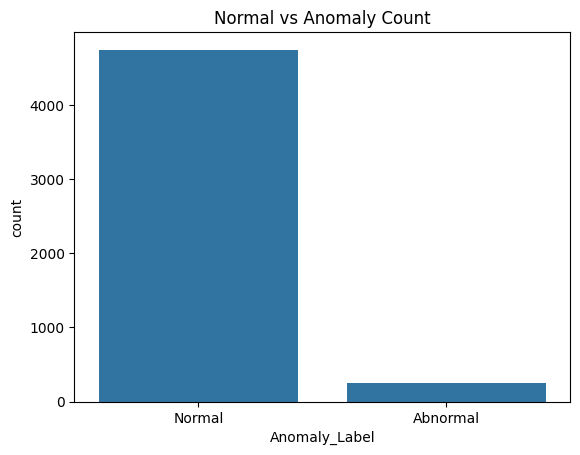

In [ ]:
sns.countplot(x=df['Anomaly_Label'])
plt.title("Normal vs Anomaly Count")
plt.show()

In [ ]:
#dataset is imbalanced (Normal >> Abnormal)

In [ ]:
#هيبصمج بصمجة قوية خلوا بالكم

Histogram

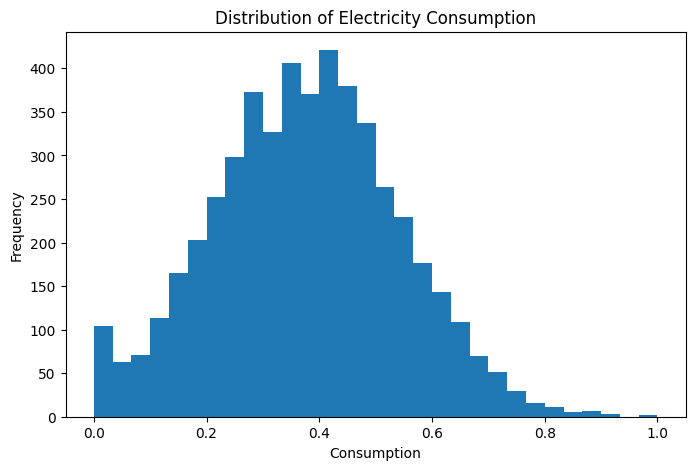

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Electricity_Consumed'], bins=30)
plt.title("Distribution of Electricity Consumption")
plt.xlabel("Consumption")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# اغلب الناس ف الداتا استهلاكها متوسط بس عندنا شوية حرامية ف الاطراف

Boxplot to find outlier

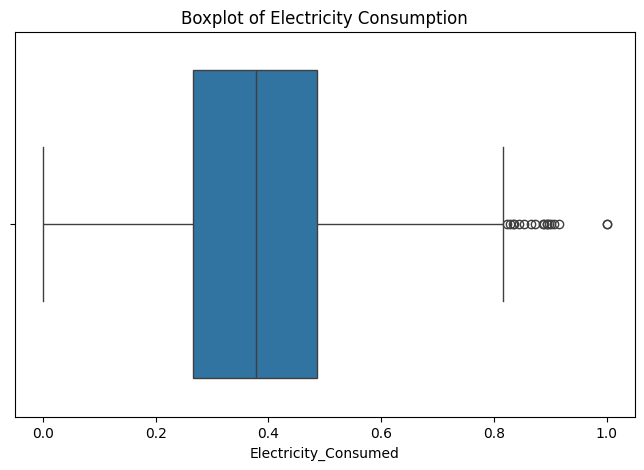

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Electricity_Consumed'])
plt.title("Boxplot of Electricity Consumption")
plt.show()

In [ ]:
#There are outliers in electricity consumption indicating abnormal behavior

In [ ]:
#عندنا شوية نقط بعيد عن الاستهلاك الطبيعي يعني شوية سرقة عايزين الموديل يكتشفها

Heatmap

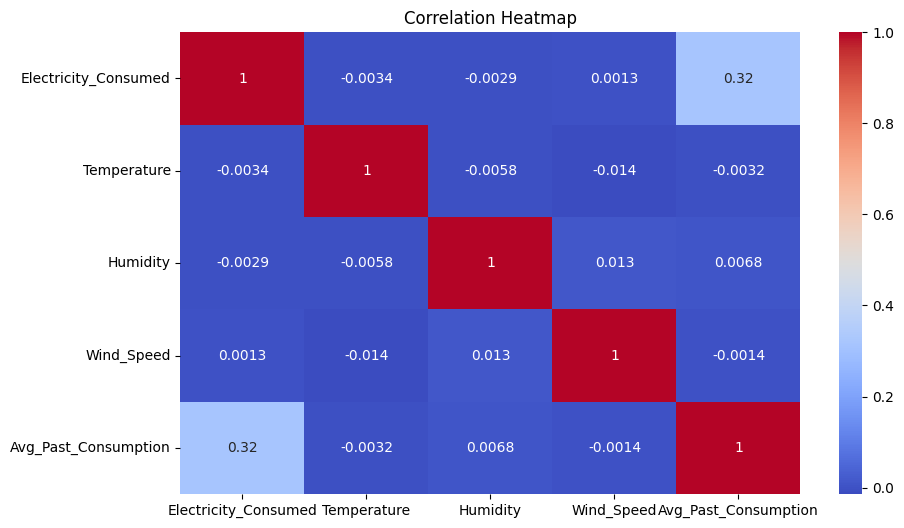

In [ ]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Scatter

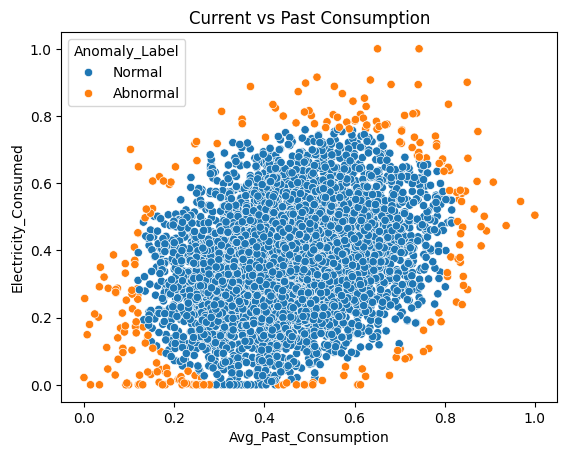

In [ ]:
sns.scatterplot(x=df['Avg_Past_Consumption'], y=df['Electricity_Consumed'], hue=df['Anomaly_Label'])
plt.title("Current vs Past Consumption")
plt.show()

In [ ]:
#Some records don't follow the expected relationship between past and current consumption

In [ ]:
#في استهلاك اتغير بجنون

Time plot

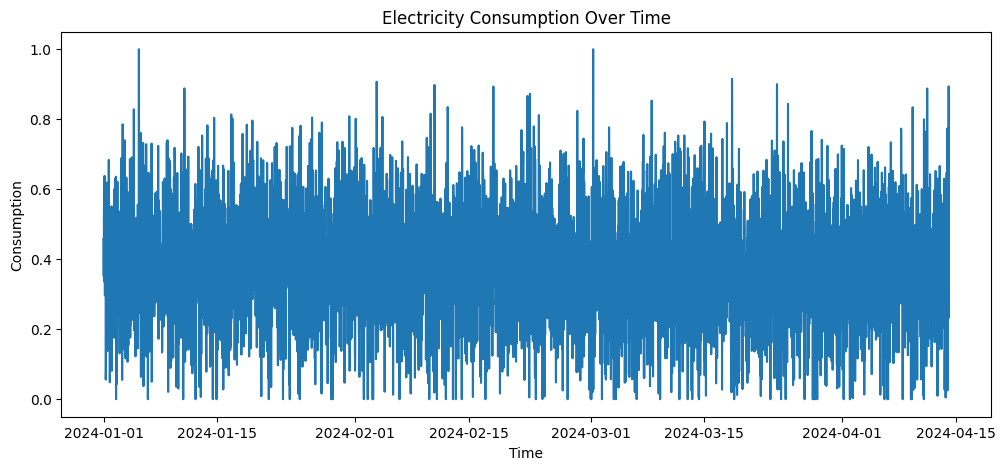

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

plt.figure(figsize=(12,5))
plt.plot(df['Timestamp'], df['Electricity_Consumed'])
plt.title("Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.show()

In [ ]:
#هنا بنشوف الاستهلاك بيتغير ازاي بمرور الوقت

In [ ]:
#drop & spike غالبا سرقة

 Prepare feature matrix and target column for the next stage

In [ ]:
X = df[['Electricity_Consumed', 'Temperature', 'Humidity', 'Wind_Speed', 'Avg_Past_Consumption']]
y = df['Anomaly_Label']

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())
print(y.head())

X shape: (5000, 5)
y shape: (5000,)
   Electricity_Consumed  Temperature  Humidity  Wind_Speed  \
0              0.457786     0.469524  0.396368    0.445441   
1              0.351956     0.465545  0.451184    0.458729   
2              0.482948     0.285415  0.408289    0.470360   
3              0.628838     0.482095  0.512308    0.576241   
4              0.335974     0.624741  0.672021    0.373004   

   Avg_Past_Consumption  
0              0.692057  
1              0.539874  
2              0.614724  
3              0.757044  
4              0.673981  
0    Normal
1    Normal
2    Normal
3    Normal
4    Normal
Name: Anomaly_Label, dtype: object


**Note:**

The dataset is imbalanced (Normal > Abnormal)  ▶  (للتأكيد )




**Data preparation**


In [ ]:
# Convert from string to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sort data by time for LSTM to ensure correct sequence learning
df = df.sort_values('Timestamp')

df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


**Label Encoding**

In [ ]:
# Convert labels to numeric
df['Anomaly_Label'] = df['Anomaly_Label'].map({
    'Normal': 0,
    'Abnormal': 1
})

df['Anomaly_Label'].value_counts()
#  Normal = 0 , Theft = 1

,count
Anomaly_Label,
0,4750
1,250


**Feature Engineering**

In [ ]:
# Create new feature: difference between current and past consumption that will directly capture abnormal behavior
df['Consumption_Diff'] = (
    df['Electricity_Consumed'] - df['Avg_Past_Consumption']
)

df.head()



,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label,Consumption_Diff
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,0,-0.234272
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,0,-0.187918
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,0,-0.131776
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,0,-0.128206
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,0,-0.338007


In [ ]:
# Positive values -- ((theft) spike)
# Negative values -- (potential drop)

**Feature Scaling**
(normalizing using MinMaxScaler)

In [ ]:
# Used MinMaxScaler because input should be in a small bounded range because LSTM uses: Sigmoid activation -- outputs between (0,1) ,Tanh activation -- outputs between (-1,1)
# any other scaler will lead to unstable results

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = [
    'Electricity_Consumed',
    'Temperature',
    'Humidity',
    'Wind_Speed',
    'Avg_Past_Consumption',
    'Consumption_Diff'
]

scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label,Consumption_Diff
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,0,0.336864
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,0,0.373827
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,0,0.418596
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,0,0.421443
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,0,0.254144



**Train/Test Split**


In [ ]:
# Split based on time
split = int(0.8 * len(df))

train_df = df.iloc[:split]
test_df = df.iloc[split:]

print("Train size:", len(train_df))
print("Test size:", len(test_df))
# To Prevents data leakage

Train size: 4000
Test size: 1000



**Applying SMOTE on training data only**


In [ ]:
from imblearn.over_sampling import SMOTE

X_train = train_df[features]
y_train = train_df['Anomaly_Label']

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Before SMOTE:
 Anomaly_Label
0    3805
1     195
Name: count, dtype: int64

After SMOTE:
 Anomaly_Label
0    3805
1    3805
Name: count, dtype: int64


In [ ]:

# Model learns:Patterns from balanced training data
#Then tested on: Real world data (test set Represents real world data, Still imbalanced (like reality))
# So the accuracy is honest


**Prepare Test Data**
 (nothing changed)


In [ ]:
# Test data must remain realistic
X_test = test_df[features]
y_test = test_df['Anomaly_Label']


**Converts data → sequences**



In [ ]:
# LSTM learns patterns over time from sequences
def create_sequences(X, y, time_steps=10):
    X_seq, y_seq = [], []

    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])

    return np.array(X_seq), np.array(y_seq)


**Apply Sequence Creation**



In [ ]:
time_steps = 10

# Training sequences
X_train_seq, y_train_seq = create_sequences(
    X_train_resampled.values,
    y_train_resampled.values,
    time_steps
)

# Testing sequences
X_test_seq, y_test_seq = create_sequences(
    X_test.values,
    y_test.values,
    time_steps
)

print("Train shape:", X_train_seq.shape)
print("Test shape:", X_test_seq.shape)

Train shape: (7600, 10, 6)
Test shape: (990, 10, 6)


In [ ]:
df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label,Consumption_Diff
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,0,0.336864
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,0,0.373827
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,0,0.418596
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,0,0.421443
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,0,0.254144


In [ ]:
# S# ==============================
# 1. Save TRAIN data (after SMOTE + sequences)
# ==============================

# Flatten sequences to 2D for saving
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)

train_df_final = pd.DataFrame(X_train_flat)
train_df_final['Target'] = y_train_seq

train_df_final.to_csv("train_data_lstm.csv", index=False)


# ==============================
# 2. Save TEST data (original sequences)
# ==============================

X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

test_df_final = pd.DataFrame(X_test_flat)
test_df_final['Target'] = y_test_seq

test_df_final.to_csv("test_data_lstm.csv", index=False)


# ==============================
# 3. Save MERGED data (train + test)
# ==============================

merged_df = pd.concat([train_df_final, test_df_final], axis=0)

merged_df.to_csv("merged_data_lstm.csv", index=False)


print("✅ Files saved successfully:")
print("- train_data_lstm.csv")
print("- test_data_lstm.csv")
print("- merged_data_lstm.csv")

✅ Files saved successfully:
- train_data_lstm.csv
- test_data_lstm.csv
- merged_data_lstm.csv
